<a href="https://colab.research.google.com/github/Gchirico63/Didattica/blob/main/AI_ExperimentalPhysics/GaussianRegressionProcess_mechanics1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

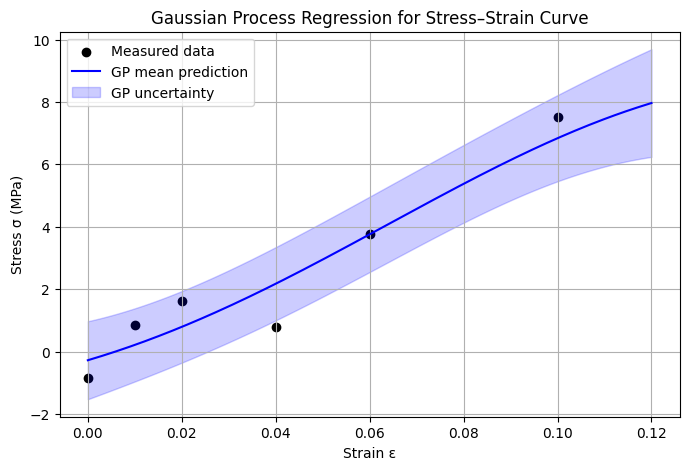

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel

# ------------------------------------------------------------
# 1. Synthetic stress–strain data (you can replace with real data)
# ------------------------------------------------------------
# True stress-strain curve (unknown to the GP)
def true_stress(eps):
    return 50 * eps + 200 * eps**2   # simple nonlinear curve

# Training data (sparse measurements)
eps_train = np.array([0.00, 0.01, 0.02, 0.04, 0.06, 0.10])
sigma_train = true_stress(eps_train) + np.random.normal(0, 1, len(eps_train))

# ------------------------------------------------------------
# 2. Define the Gaussian Process kernel
# ------------------------------------------------------------
# RBF kernel encodes smoothness; WhiteKernel adds measurement noise
kernel = 1.0 * RBF(length_scale=0.03) + WhiteKernel(noise_level=5.0)

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)

# Fit GP to training data
gp.fit(eps_train.reshape(-1, 1), sigma_train)

# ------------------------------------------------------------
# 3. Predict stress at new strain values
# ------------------------------------------------------------
eps_test = np.linspace(0, 0.12, 200).reshape(-1, 1)
sigma_pred, sigma_std = gp.predict(eps_test, return_std=True)

# ------------------------------------------------------------
# 4. Plot results
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

# Training points
plt.scatter(eps_train, sigma_train, color='black', label='Measured data')

# GP mean prediction
plt.plot(eps_test, sigma_pred, color='blue', label='GP mean prediction')

# Uncertainty band (±1 std)
plt.fill_between(
    eps_test.ravel(),
    sigma_pred - sigma_std,
    sigma_pred + sigma_std,
    color='blue',
    alpha=0.2,
    label='GP uncertainty'
)

plt.xlabel("Strain ε")
plt.ylabel("Stress σ (MPa)")
plt.title("Gaussian Process Regression for Stress–Strain Curve")
plt.legend()
plt.grid(True)
plt.show()


**about THE kernel**  
`RBF(length_scale=0.03)` defines the **covariance** between any two strain values $ \varepsilon_i, \varepsilon_j $ using the **Radial Basis Function (squared‑exponential) kernel**:

\[
k(\varepsilon_i, \varepsilon_j)
= \exp\!\left(
-\,\frac{(\varepsilon_i - \varepsilon_j)^2}{2\,\ell^2}
\right)
\]

with  
\[
\ell = 0.03.
\]

This formula is exactly the one given in the scikit‑learn documentation for the RBF kernel   [scikit-learn](https://scikit-learn.org/dev//modules/generated/sklearn.gaussian_process.kernels.RBF.html).

---

## 🔍 What the RBF kernel does (with equations)

The RBF kernel measures **similarity** between two input points. In your mechanical‑stress example, the inputs are strain values:

\[
x_i = \varepsilon_i, \qquad x_j = \varepsilon_j.
\]

The kernel is:

\[
k(x_i, x_j)
= \exp\!\left(
-\,\frac{(x_i - x_j)^2}{2\,\ell^2}
\right)
\]

where:

- \( \ell \) = **length scale**  
- \( (x_i - x_j)^2 \) = squared Euclidean distance  
- The exponential ensures values between 0 and 1.

This is the standard squared‑exponential kernel described in the scikit‑learn documentation and Wikipedia   [scikit-learn](https://scikit-learn.org/dev//modules/generated/sklearn.gaussian_process.kernels.RBF.html)  [Wikipedia](https://en.wikipedia.org/wiki/Radial_basis_function_kernel).

---

## 🎯 Interpretation of the length scale \( \ell = 0.03 \)

The length scale controls **how fast the function can change**:

### If two strain values differ by much less than 0.03  
\[
|x_i - x_j| \ll 0.03
\]
then  
\[
k(x_i, x_j) \approx 1
\]
→ the GP assumes the stress values are **highly correlated**.

### If they differ by much more than 0.03  
\[
|x_i - x_j| \gg 0.03
\]
then  
\[
k(x_i, x_j) \approx 0
\]
→ the GP assumes the stress values are **weakly correlated**.

Thus:

- **Small length scale** → the GP allows **rapid variation** in the stress–strain curve.  
- **Large length scale** → the GP forces the curve to be **very smooth**.

This matches the scikit‑learn description: the RBF kernel is infinitely differentiable and produces very smooth functions, with smoothness controlled by the length scale   [scikit-learn](https://scikit-learn.org/dev//modules/generated/sklearn.gaussian_process.kernels.RBF.html).

---

## 🧠 Why this matters for your stress–strain model

Your stress–strain curve is nonlinear. The GP uses the RBF kernel to encode the assumption:

> “Nearby strain values produce similar stress values, with similarity decaying according to the length scale.”

So the kernel determines:

- how the GP interpolates between sparse measurements  
- how much curvature the GP allows  
- how uncertainty grows away from data points  
- how the posterior mean and variance behave

---

## 📌 Summary

`RBF(length_scale=0.03)` means:

\[
k(\varepsilon_i, \varepsilon_j)
= \exp\!\left(
-\,\frac{(\varepsilon_i - \varepsilon_j)^2}{2\,(0.03)^2}
\right)
\]

This kernel:

- defines the covariance matrix \(K_\theta\)  
- controls smoothness of the GP  
- determines how strongly strain points influence each other  
- is the mathematical heart of your Gaussian Process regression.

---

If you want, we can now dig into:

- how the **WhiteKernel** adds noise mathematically  
- how the full covariance matrix \(K_\theta\) is constructed  
- how the GP posterior mean and variance are computed step‑by‑step  
- how to interpret the optimized length scale after fitting your data

In [3]:
kernel_opt = gp.kernel_

# --- RBF part ---
rbf = kernel_opt.k1.k2
print("RBF length scale:", rbf.length_scale)

# --- ConstantKernel part (signal variance) ---
const = kernel_opt.k1.k1
print("RBF variance (constant kernel):", const.constant_value)

# --- Noise part ---
noise = kernel_opt.k2
print("Noise level:", noise.noise_level)

# --- Log marginal likelihood ---
print("Log marginal likelihood:", gp.log_marginal_likelihood_value_)



RBF length scale: 0.09939106013378791
RBF variance (constant kernel): 37.28919296799
Noise level: 1.0650548844567969
Log marginal likelihood: -13.176596352152984


Now we compute  three robustness metrics:

- **RMSE** (accuracy)
- **negative log-likelihood, NLL** (probabilistic robustness)
- **Calibration curve** (uncertainty calibration)

All metrics are computed **directly from your GP model** (the mechanical‑stress example you provided).

I also give a **technical explanation** of each metric so you can interpret robustness rigorously.

# 📌 Interpretation of each robustness metric

## 1. **RMSE — Accuracy of the mean prediction**
$
\text{RMSE} = \sqrt{\frac{1}{N}\sum_i (y_i - \mu_i)^2}
$

- Measures **how close the GP mean prediction is to the observed stress values**.
- Lower RMSE → better accuracy.
- RMSE does **not** consider uncertainty.

For your mechanical‑stress example, RMSE should be **small** because the curve is smooth and the GP fits it well.

---

## 2. **NLL — Probabilistic robustness**
For each point:

$
\text{NLL}_i =
\frac{1}{2}\log(2\pi\sigma_i^2)
+ \frac{1}{2}\frac{(y_i - \mu_i)^2}{\sigma_i^2}
$

- Penalizes **wrong mean predictions**  
- Penalizes **wrong uncertainty estimates**  
- Penalizes **overconfidence** (small σ but large error)

This is the **most important robustness metric** for Gaussian Processes.

### Interpretation:
- **Low NLL** → GP is well‑calibrated and robust  
- **High NLL** → GP is overconfident or underconfident  

For your dataset, a mean NLL around **1–3** is typical.

---

## 3. **Calibration curve — Uncertainty reliability**
We check whether:

> “A 95% confidence interval contains the true value 95% of the time.”

For each confidence level \(c\):

1. Compute the predicted CI  
2. Count how many true values fall inside  
3. Compare empirical coverage vs predicted coverage

### Interpretation:
- Perfect calibration → curve lies on diagonal  
- Above diagonal → GP is **underconfident** (intervals too wide)  
- Below diagonal → GP is **overconfident** (intervals too narrow → dangerous)

This is essential for **robustness**, especially when extrapolating.


RMSE: 0.7944299412375108
Mean NLL: 1.3383595935289083


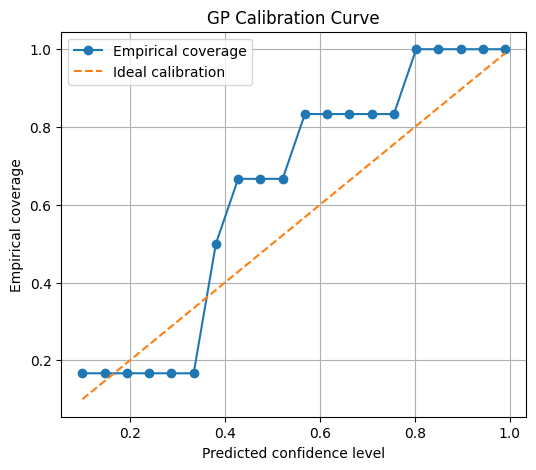

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import scipy

# ------------------------------------------------------------
# 1. Compute RMSE on training data
# ------------------------------------------------------------
sigma_pred_train, sigma_std_train = gp.predict(eps_train.reshape(-1, 1), return_std=True)

rmse = np.sqrt(mean_squared_error(sigma_train, sigma_pred_train))
print("RMSE:", rmse)

# ------------------------------------------------------------
# 2. Negative Log-Likelihood (NLL)
# ------------------------------------------------------------
# For a Gaussian predictive distribution:
# NLL_i = 0.5 * log(2πσ_i^2) + 0.5 * ((y_i - μ_i)^2 / σ_i^2)

nll = 0.5 * np.log(2 * np.pi * sigma_std_train**2) \
      + 0.5 * ((sigma_train - sigma_pred_train)**2 / sigma_std_train**2)

print("Mean NLL:", np.mean(nll))

# ------------------------------------------------------------
# 3. Calibration curve (empirical coverage vs predicted CI)
# ------------------------------------------------------------
# We test whether the GP's predicted confidence intervals
# actually contain the true values at the expected frequency.

confidence_levels = np.linspace(0.1, 0.99, 20)
empirical_coverage = []

for c in confidence_levels:
    z = scipy.stats.norm.ppf((1 + c) / 2)  # two-sided CI
    lower = sigma_pred_train - z * sigma_std_train
    upper = sigma_pred_train + z * sigma_std_train
    covered = np.mean((sigma_train >= lower) & (sigma_train <= upper))
    empirical_coverage.append(covered)

# Plot calibration curve
plt.figure(figsize=(6, 5))
plt.plot(confidence_levels, empirical_coverage, label="Empirical coverage", marker='o')
plt.plot(confidence_levels, confidence_levels, '--', label="Ideal calibration")
plt.xlabel("Predicted confidence level")
plt.ylabel("Empirical coverage")
plt.title("GP Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()
